# Use the Model

Load the released checkpoint and predict an RNFLT map from the sample OCT fundus image.

In [1]:
from octfundus2rnflt import *

## Load the sample OCT fundus

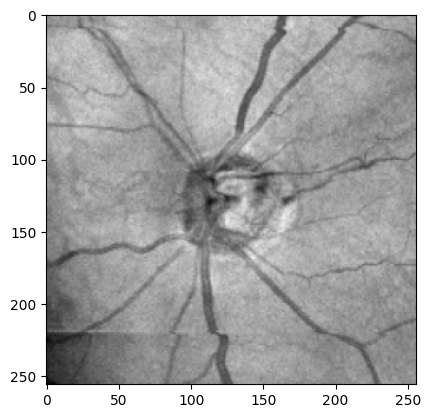

In [2]:
oct_fundus = cv2.resize(cv2.imread('samples/sample_oct_fundus.png', 0), (256, 256))
img = np.array([np.transpose(np.array([oct_fundus, oct_fundus, oct_fundus]), (1, 2, 0))])
mask = np.ones_like(img)

plt.imshow(oct_fundus, cmap='gray')
plt.show()

## Load the pretrained model and predict

/data/home/shim/miniconda3/envs/env_tf24/lib/python3.8/site-packages/tensorflow/python/keras/engine/training.py:2325: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


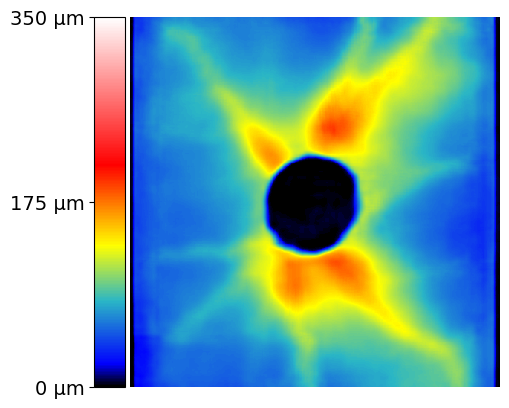

In [4]:
# load the pretrained model
octfundus2rnflt = PCModel(img_rows=256, img_cols=256)
octfundus2rnflt.load('checkpoint/octfundus_to_rnflt_new2.final.h5', train_bn=False, lr=0.00001)

# RNFLT prediction
pred = octfundus2rnflt.model.predict([img, mask])[0][:,:,0]
plot_2dmap(pred, show_cup=False)